# Anomaly Detection Pipeline

This is the production pipeline that runs all detectors on the feature data
and saves the flagged results. It produces:

- Rule-based flags from `add_rule_flags`: physical/sensor constraint violations.
- ML-based flags from `add_ml_flags` with Isolation Forest: subtle anomalies
  that no single threshold rule catches.

The output (`apc_flagged.csv`) is the basis for the report and presentation.

## 1. Setup

Load the engineered features file. All later cells operate on `apc_features`
in memory.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

from src.detection import add_rule_flags, add_ml_flags

apc_features = pd.read_csv('../data/processed/apc_features.csv',
                            sep=';', encoding='latin-1')

print(f"Loaded apc_features: {apc_features.shape}")

Loaded apc_features: (1598277, 39)


## 2. Run rule-based detectors

Apply four physical/sensor constraint rules:
- `flag_negative_load`: load went below zero (impossible)
- `flag_capacity_exceeded`: load exceeded 100 passengers
- `flag_gps_zero`: GPS reported (0, 0)
- `flag_gps_outside_halland`: GPS outside the region bounding box

These are the "trivial" baseline detectors that the examiner correctly
pointed out are not enough on their own.

In [2]:
flagged = add_rule_flags(apc_features)

print(f"After rules: {flagged.shape}")
print()

# Row-level rules
print("Row-level flags:")
print(f"  flag_gps_zero:            {flagged['flag_gps_zero'].sum():,}")
print(f"  flag_gps_outside_halland: {flagged['flag_gps_outside_halland'].sum():,}")
print()

# Trip-level rules
trips = flagged.dropna(subset=['trip']).drop_duplicates(['vehicleCode', 'trip', 'date'])
print(f"Total trips: {len(trips):,}")
print("Trip-level flags:")
print(f"  flag_negative_load:     {trips['flag_negative_load'].sum():,}")
print(f"  flag_capacity_exceeded: {trips['flag_capacity_exceeded'].sum():,}")

After rules: (1598277, 43)

Row-level flags:
  flag_gps_zero:            18,399
  flag_gps_outside_halland: 18,409

Total trips: 64,172
Trip-level flags:
  flag_negative_load:     24,943
  flag_capacity_exceeded: 1


## 3. Run ML detector: Isolation Forest

Apply the generic `add_ml_flags` function with an Isolation Forest model.
The function works with any sklearn estimator that has `fit()` and
`score_samples()`, so swapping in another algorithm (e.g. LOF) is one line.

We flag the 5% most anomalous trips — `random_state=42` ensures reproducible
results across runs.

In [3]:
flagged = add_ml_flags(
    flagged,
    model=IsolationForest(contamination=0.05, random_state=42),
    name='if',
    threshold_pct=5,
)

print(f"After ML: {flagged.shape}")
print()

# Refresh trip-level table to include the new ML columns
trips = flagged.dropna(subset=['trip']).drop_duplicates(['vehicleCode', 'trip', 'date'])

print(f"ML-flagged trips: {trips['flag_if'].sum():,}  "
      f"({trips['flag_if'].sum() / len(trips) * 100:.1f}%)")

After ML: (1598277, 45)

ML-flagged trips: 3,209  (5.0%)


## 4. Compare rules vs ML

The examiner pointed out that anomalies catchable by simple thresholds are
not very interesting. The real value of an ML detector is finding trips
that look unusual in the *combination* of features but don't trigger any
single threshold rule.

We cross-tabulate the two flag categories:
- **Rules only**: rules see it, ML doesn't (often: minor negative load that's not unusual)
- **ML only**: ML sees it, no rule fires (the interesting set)
- **Both**: obvious failures confirmed by ML
- **Neither**: clean trips

In [4]:
# Combine all trip-level rule flags into one column.
# We exclude GPS rules here because they are row-level and a single bad GPS
# row does not necessarily make the whole trip an anomaly.
trips['flag_rules'] = trips['flag_negative_load'] | trips['flag_capacity_exceeded']

n_total      = len(trips)
n_rules_only = ((trips['flag_rules']) & (~trips['flag_if'])).sum()
n_ml_only    = ((~trips['flag_rules']) & (trips['flag_if'])).sum()
n_both       = ((trips['flag_rules']) & (trips['flag_if'])).sum()
n_neither    = ((~trips['flag_rules']) & (~trips['flag_if'])).sum()

print(f"Total trips: {n_total:,}")
print()
print(f"  Rules only:  {n_rules_only:>6,}  ({n_rules_only/n_total*100:5.1f}%)")
print(f"  ML only:     {n_ml_only:>6,}  ({n_ml_only/n_total*100:5.1f}%)")
print(f"  Both:        {n_both:>6,}  ({n_both/n_total*100:5.1f}%)")
print(f"  Neither:     {n_neither:>6,}  ({n_neither/n_total*100:5.1f}%)")

Total trips: 64,172

  Rules only:  24,944  ( 38.9%)
  ML only:      1,328  (  2.1%)
  Both:         1,881  (  2.9%)
  Neither:     39,228  ( 61.1%)


## 5. Inspect ML-only trips

These are the trips flagged by Isolation Forest but missed by every rule —
the direct answer to the examiner's feedback. We sort by ML score (lowest
score = most anomalous) and look at their feature values.

If ML is doing useful work, these trips should look subtly unusual: high
imbalance without negative load, or extreme z-scores, or unusual
combinations of multiple features.

In [5]:
ml_only = trips[(trips['flag_if']) & (~trips['flag_rules'])].copy()
ml_only = ml_only.sort_values('score_if')   # lowest score first = most anomalous

print(f"ML-only trips: {len(ml_only):,}")
print()
print("Top 10 most anomalous ML-only trips:")

cols = ['vehicleCode', 'trip', 'date', 'line',
        'trip_total_boardings', 'trip_total_alightings',
        'trip_imbalance', 'trip_n_stops',
        'trip_min_load', 'trip_max_load', 'trip_imbalance_z_score',
        'score_if']
print(ml_only[cols].head(10).to_string(index=False))

# Note any vehicle that appears repeatedly — likely a systemic sensor issue
print()
print("Vehicles most often in the top-100 ML-only trips:")
print(ml_only.head(100)['vehicleCode'].value_counts().head(5).to_string())

ML-only trips: 1,328

Top 10 most anomalous ML-only trips:
 vehicleCode  trip       date   line  trip_total_boardings  trip_total_alightings  trip_imbalance  trip_n_stops  trip_min_load  trip_max_load  trip_imbalance_z_score  score_if
        3630  31.0 2025-01-13  652.0                  90.0                   46.0            44.0          28.0           20.0           63.0                5.281303 -0.768594
        3630  45.0 2025-01-31  615.0                 112.0                   33.0            79.0          57.0            5.0           79.0                7.370621 -0.766347
        3630  26.0 2025-01-29  615.0                  90.0                   55.0            35.0          59.0           11.0           71.0                3.152535 -0.765999
        7989  10.0 2025-01-30  350.0                 111.0                   64.0            47.0          42.0            0.0           86.0                9.120576 -0.765999
        3630   5.0 2025-01-09  614.0                  96.0   

## 6. Visualization

Three plots that summarise the detection results:

1. **Detection overlap** — bar chart of the four cross-tab categories.
2. **Score distribution** — histogram of `score_if` with the ML cutoff line.
3. **Anomaly map** — scatter of trip imbalance vs max load, coloured by which
   detector flagged the trip. Shows visually where ML and rules disagree.

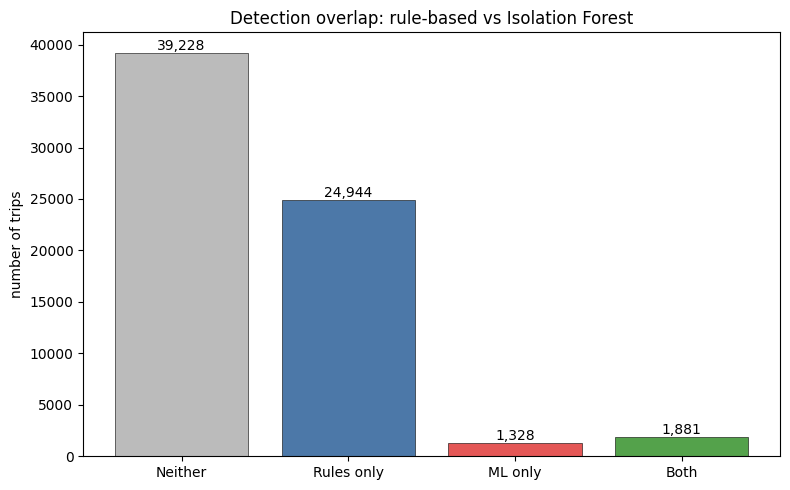

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Neither', 'Rules only', 'ML only', 'Both']
counts     = [n_neither, n_rules_only, n_ml_only, n_both]
colors     = ['#bbbbbb', '#4c78a8', '#e45756', '#54a24b']

bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=0.4)
ax.set_ylabel('number of trips')
ax.set_title('Detection overlap: rule-based vs Isolation Forest')

# Add value labels on top of each bar
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{c:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

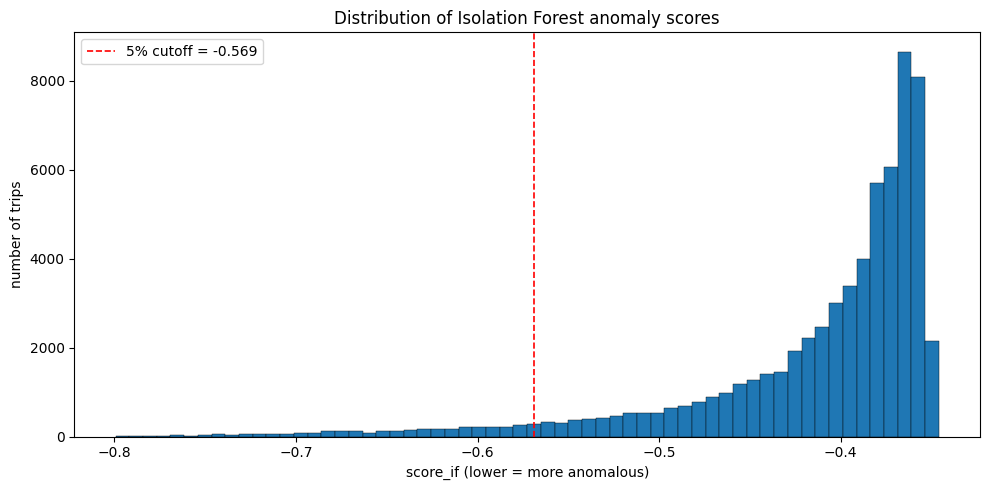

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(trips['score_if'], bins=60, edgecolor='black', linewidth=0.3)

# Cutoff line at the 5th percentile
cutoff = trips['score_if'].quantile(0.05)
ax.axvline(cutoff, color='red', linestyle='--', linewidth=1.2,
           label=f'5% cutoff = {cutoff:.3f}')

ax.set_xlabel('score_if (lower = more anomalous)')
ax.set_ylabel('number of trips')
ax.set_title('Distribution of Isolation Forest anomaly scores')
ax.legend()

plt.tight_layout()
plt.show()

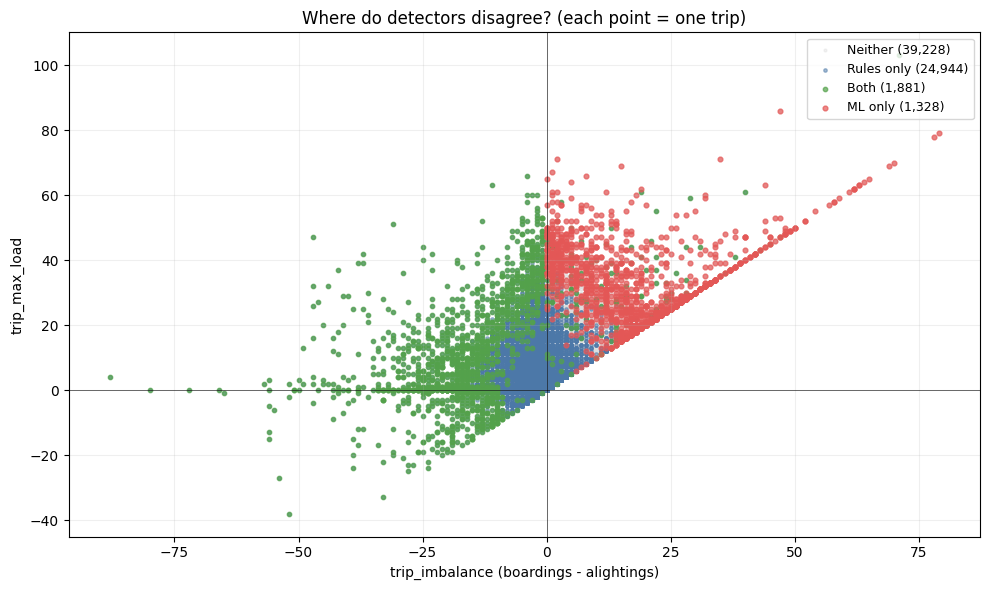

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

# Color by category - plot in order so important groups end up on top
sub_neither    = trips[(~trips['flag_rules']) & (~trips['flag_if'])]
sub_rules_only = trips[(trips['flag_rules'])  & (~trips['flag_if'])]
sub_both       = trips[(trips['flag_rules'])  & (trips['flag_if'])]
sub_ml_only    = trips[(~trips['flag_rules']) & (trips['flag_if'])]

ax.scatter(sub_neither['trip_imbalance'],    sub_neither['trip_max_load'],
           s=4, c='#dddddd', alpha=0.4, label=f'Neither ({len(sub_neither):,})')
ax.scatter(sub_rules_only['trip_imbalance'], sub_rules_only['trip_max_load'],
           s=6, c='#4c78a8', alpha=0.5, label=f'Rules only ({len(sub_rules_only):,})')
ax.scatter(sub_both['trip_imbalance'],       sub_both['trip_max_load'],
           s=10, c='#54a24b', alpha=0.7, label=f'Both ({len(sub_both):,})')
ax.scatter(sub_ml_only['trip_imbalance'],    sub_ml_only['trip_max_load'],
           s=12, c='#e45756', alpha=0.7, label=f'ML only ({len(sub_ml_only):,})')

ax.set_xlabel('trip_imbalance (boardings - alightings)')
ax.set_ylabel('trip_max_load')
ax.set_title('Where do detectors disagree? (each point = one trip)')
ax.axhline(0, color='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.4)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Save results

Save the fully flagged DataFrame for reuse in the report and presentation.
This file contains all features plus all rule flags and ML scores/flags.

In [9]:
flagged.to_csv('../data/processed/apc_flagged.csv',
               sep=';', index=False, encoding='latin-1')

print("Saved to ../data/processed/apc_flagged.csv")
print(f"Rows:    {len(flagged):,}")
print(f"Columns: {flagged.shape[1]}")

Saved to ../data/processed/apc_flagged.csv
Rows:    1,598,277
Columns: 45
